# Sanity Check – `siamese_best.pth`
1. Load model + data
2. Compute F1 / Precision / Recall on `val_pairs_improved.csv`
3. Visual demo: pick random pairs, show images + titles + model prediction

In [1]:
import os, pickle, random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix

pd.options.display.max_colwidth = 80

DATA_FOLDER      = "../data/"
IMAGES_FOLDER    = "../../images/"
PIPELINES_FOLDER = "../pipelines/"
MODEL_PATH       = "../artifacts/models/siamese_hardmined.pth"
TEXT_EMB_DIM     = 512

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Running on MPS")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Running on CUDA")
else:
    device = torch.device("cpu")
    print("Running on CPU")
print(f"Device: {device}")

Running on MPS
Device: mps


## 1. Load data & embeddings

In [2]:
df_train = pd.read_csv(os.path.join(DATA_FOLDER, 'items_train.csv'))

pipeline = pickle.load(open(os.path.join(PIPELINES_FOLDER, 'preprocessing.pkl'), 'rb'))
X_train = df_train.drop(columns=['label'])
y_train = df_train['label']
df_train_transformed = pipeline.transform(X_train)
df_train_transformed['label'] = y_train.values
print(f"Train items: {len(df_train_transformed)}")

print("Loading CLIP image embeddings...")
clip_embeddings_dict = torch.load("../artifacts/embeddings/clip_image.pt", map_location='cpu', weights_only=False)
print(f"  {len(clip_embeddings_dict)} image embeddings, dim={next(iter(clip_embeddings_dict.values())).shape}")

print("Loading text embeddings...")
text_embeddings_dict = torch.load("../artifacts/embeddings/text_multilingual.pt", map_location='cpu', weights_only=False)
print(f"  {len(text_embeddings_dict)} text embeddings")

from GlamiDatasetVocabulary import GlamiVocabularyManager
vocab_manager = GlamiVocabularyManager.load_from_dir("../artifacts/vocabularies")
print(f"Vocab — geo:{len(vocab_manager.geo_dict)}, color:{len(vocab_manager.color_dict)}, dept:{len(vocab_manager.dept_dict)}")

Train items: 928234
Loading CLIP image embeddings...
  1128069 image embeddings, dim=torch.Size([768])
Loading text embeddings...
  1128069 text embeddings
Vocab — geo:13, color:94, dept:3


## 2. Re-define dataset & model classes

In [3]:
class LightweightItemDataset(Dataset):
    def __init__(self, df, vocab_manager, image_embeddings_dict, text_embeddings_dict):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab_manager
        self.image_embeddings_dict = image_embeddings_dict
        self.text_embeddings_dict = text_embeddings_dict
        self.id_to_idx = {str(row['itemId']): i for i, row in self.df.iterrows()}

    def __len__(self):
        return len(self.df)

    def _to_multi_hot(self, ids_string, vocab_dict):
        tensor = torch.zeros(len(vocab_dict), dtype=torch.float32)
        if pd.isna(ids_string) or str(ids_string).strip() == "":
            return tensor
        for raw_id in [i.strip() for i in str(ids_string).split(',') if i.strip()]:
            if raw_id in vocab_dict:
                tensor[vocab_dict[raw_id]] = 1.0
        return tensor

    def get_item_by_id(self, item_id):
        idx = self.id_to_idx.get(str(item_id))
        return None if idx is None else self[idx]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        item_id = str(row['itemId'])
        price   = torch.tensor([row['price_scaled']], dtype=torch.float32)
        geo     = torch.tensor(self.vocab.geo_dict.get(row['geo'], 0), dtype=torch.long)
        colors  = self._to_multi_hot(row['colorTagIdsString'], self.vocab.color_dict)
        depts   = self._to_multi_hot(row['departmentIds'], self.vocab.dept_dict)
        img_emb = self.image_embeddings_dict.get(item_id, torch.zeros(768, dtype=torch.float32)).cpu()
        txt_emb = self.text_embeddings_dict.get(item_id, torch.zeros(TEXT_EMB_DIM, dtype=torch.float32)).cpu()
        img_emb = F.normalize(img_emb, dim=0)
        txt_emb = F.normalize(txt_emb, dim=0)
        return {'item_id': item_id, 'price': price, 'geo': geo,
                'colors': colors, 'departments': depts,
                'image_embedding': img_emb, 'text_embedding': txt_emb}


class FastSiameseDataset(Dataset):
    def __init__(self, pairs_df, item_dataset):
        self.pairs = pairs_df.reset_index(drop=True)
        self.item_dataset = item_dataset
        self.id_to_idx = item_dataset.id_to_idx
        valid_mask = (
            self.pairs['item_id_1'].astype(str).isin(self.id_to_idx) &
            self.pairs['item_id_2'].astype(str).isin(self.id_to_idx)
        )
        self.pairs = self.pairs[valid_mask].reset_index(drop=True)
        print(f"Valid pairs: {len(self.pairs)} (dropped {(~valid_mask).sum()} missing)")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        row = self.pairs.iloc[idx]
        idx1 = self.id_to_idx[str(int(row['item_id_1']))]
        idx2 = self.id_to_idx[str(int(row['item_id_2']))]
        return self.item_dataset[idx1], self.item_dataset[idx2], torch.tensor(row['is_duplicate'], dtype=torch.float32)


def siamese_collate_fn(batch):
    items1, items2, labels = zip(*batch)
    def stack(items):
        return {k: torch.stack([it[k] for it in items]) for k in items[0] if k != 'item_id'}
    return stack(items1), stack(items2), torch.stack(list(labels))


print("Dataset classes defined.")

Dataset classes defined.


In [4]:
class SiameseEmbedder(nn.Module):
    def __init__(self, hidden_dim=256, output_dim=128):
        super().__init__()
        self.image_proj = nn.Sequential(nn.Linear(768, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(0.2))
        self.text_proj  = nn.Sequential(nn.Linear(TEXT_EMB_DIM, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(0.2))
        self.fusion     = nn.Sequential(
            nn.Linear(hidden_dim * 2 + 1, hidden_dim), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, image_emb, text_emb, price):
        return self.fusion(torch.cat([self.image_proj(image_emb), self.text_proj(text_emb), price], dim=1))


class SiameseNetwork(nn.Module):
    def __init__(self, n_colors, n_depts, n_geos, output_dim=128):
        super().__init__()
        self.embedder = SiameseEmbedder(output_dim=output_dim)
        self.classifier = nn.Sequential(
            nn.Linear(output_dim + 5, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward_one(self, item):
        return self.embedder(item['image_embedding'], item['text_embedding'], item['price'])

    @staticmethod
    def _cosine_sim(a, b): return (a * b).sum(dim=1, keepdim=True)

    @staticmethod
    def _jaccard(a, b):
        intersection = (a * b).sum(dim=1)
        union = ((a + b).clamp(max=1.0)).sum(dim=1)
        return (intersection / union.clamp(min=1e-6)).unsqueeze(1)

    @staticmethod
    def _geo_match(g1, g2): return (g1 == g2).float().unsqueeze(1)

    def forward(self, item1, item2):
        emb1, emb2 = self.forward_one(item1), self.forward_one(item2)
        diff = torch.abs(emb1 - emb2)
        combined = torch.cat([
            diff,
            self._cosine_sim(item1['image_embedding'], item2['image_embedding']),
            self._cosine_sim(item1['text_embedding'],  item2['text_embedding']),
            self._jaccard(item1['departments'], item2['departments']),
            self._jaccard(item1['colors'],      item2['colors']),
            self._geo_match(item1['geo'],        item2['geo']),
        ], dim=1)
        return self.classifier(combined).squeeze(1)


print("Model class defined.")

Model class defined.


## 3. Load `siamese_best.pth`

In [5]:
n_colors = len(vocab_manager.color_dict)
n_depts  = len(vocab_manager.dept_dict)
n_geos   = len(vocab_manager.geo_dict)

model = SiameseNetwork(n_colors, n_depts, n_geos, output_dim=128).to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)

# Support both raw state_dict and checkpoint dicts
state_dict = checkpoint.get('model_state_dict', checkpoint) if isinstance(checkpoint, dict) else checkpoint
model.load_state_dict(state_dict)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded  ({total_params:,} params)")
if isinstance(checkpoint, dict) and 'best_f1' in checkpoint:
    print(f"Saved best F1 (from checkpoint): {checkpoint['best_f1']:.4f}")

Model loaded  (519,169 params)


## 4. Evaluate on val pairs

In [6]:
# Build item dataset
item_dataset = LightweightItemDataset(df_train_transformed, vocab_manager,
                                       clip_embeddings_dict, text_embeddings_dict)

# Load val pairs (use a reasonable subset for speed)
val_pairs_full = pd.read_csv("../artifacts/pairs/val_pairs.csv")
pos_val = val_pairs_full[val_pairs_full['is_duplicate'] == 1.0]
neg_val = val_pairs_full[val_pairs_full['is_duplicate'] == 0.0]
n_pos = min(len(pos_val), 20_000)
n_neg = min(len(neg_val), 80_000)
val_pairs = pd.concat([
    pos_val.sample(n=n_pos, random_state=42),
    neg_val.sample(n=n_neg, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Val pairs: {len(val_pairs)}  ({n_pos} pos / {n_neg} neg)")

val_siamese = FastSiameseDataset(val_pairs, item_dataset)
val_loader  = DataLoader(val_siamese, batch_size=512, shuffle=False,
                         num_workers=0, collate_fn=siamese_collate_fn)

Val pairs: 100000  (20000 pos / 80000 neg)
Valid pairs: 100000 (dropped 0 missing)


In [7]:
def move_to_device(d, dev):
    return {k: v.to(dev) if isinstance(v, torch.Tensor) else v for k, v in d.items()}

all_probs, all_labels = [], []
model.eval()
with torch.no_grad():
    for item1, item2, labels in tqdm(val_loader, desc="Evaluating"):
        item1 = move_to_device(item1, device)
        item2 = move_to_device(item2, device)
        logits = model(item1, item2)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
print("Done!")

Evaluating: 100%|██████████| 196/196 [00:10<00:00, 19.49it/s]

Done!


In [8]:
# Sweep thresholds to find best F1
thresholds = np.arange(0.1, 0.91, 0.05)
results = []
for t in thresholds:
    preds = (all_probs >= t).astype(int)
    results.append({
        'threshold': t,
        'f1':        f1_score(all_labels, preds, zero_division=0),
        'precision': precision_score(all_labels, preds, zero_division=0),
        'recall':    recall_score(all_labels, preds, zero_division=0),
    })
results_df = pd.DataFrame(results)

best_row = results_df.loc[results_df['f1'].idxmax()]
print(results_df.to_string(index=False, float_format='%.3f'))
print(f"\n★  Best threshold: {best_row.threshold:.2f}  →  F1={best_row.f1:.4f}  P={best_row.precision:.4f}  R={best_row.recall:.4f}")

 threshold    f1  precision  recall
     0.100 0.972      0.987   0.957
     0.150 0.970      0.991   0.949
     0.200 0.967      0.993   0.943
     0.250 0.964      0.994   0.936
     0.300 0.962      0.995   0.931
     0.350 0.959      0.996   0.925
     0.400 0.957      0.997   0.920
     0.450 0.954      0.997   0.914
     0.500 0.952      0.998   0.910
     0.550 0.949      0.998   0.905
     0.600 0.946      0.998   0.899
     0.650 0.943      0.999   0.894
     0.700 0.940      0.999   0.887
     0.750 0.936      0.999   0.880
     0.800 0.931      0.999   0.871
     0.850 0.926      1.000   0.862
     0.900 0.918      1.000   0.848

★  Best threshold: 0.10  →  F1=0.9720  P=0.9873  R=0.9573


Classification report (threshold=0.10)
               precision    recall  f1-score   support

not_duplicate       0.99      1.00      0.99     80000
    duplicate       0.99      0.96      0.97     20000

     accuracy                           0.99    100000
    macro avg       0.99      0.98      0.98    100000
 weighted avg       0.99      0.99      0.99    100000



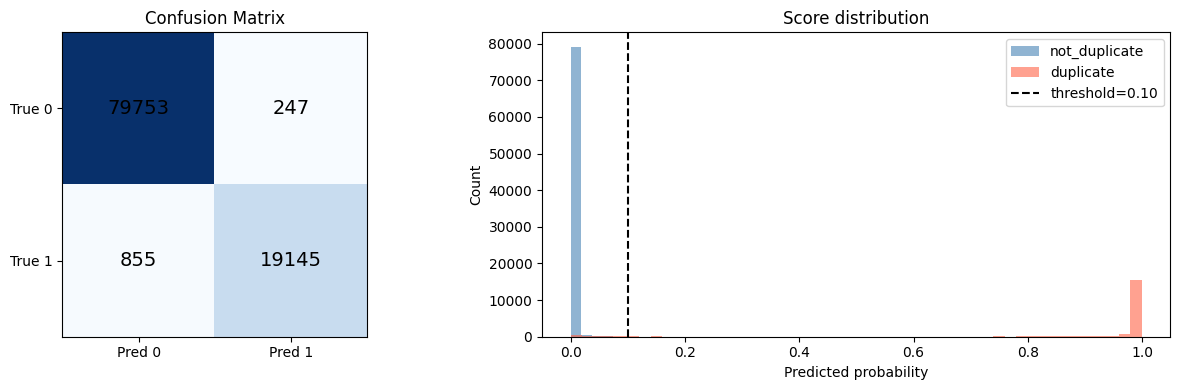

In [ ]:
# Full report at best threshold
THRESHOLD = float(best_row.threshold)
preds = (all_probs >= THRESHOLD).astype(int)

print(f"Classification report (threshold={THRESHOLD:.2f})")
print(classification_report(all_labels, preds, target_names=['not_duplicate', 'duplicate']))

cm = confusion_matrix(all_labels, preds)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
ax = axes[0]
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred 0', 'Pred 1'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['True 0', 'True 1'])
ax.set_title('Confusion Matrix')

# Score distribution
ax2 = axes[1]
ax2.hist(all_probs[all_labels == 0], bins=50, alpha=0.6, label='not_duplicate', color='steelblue')
ax2.hist(all_probs[all_labels == 1], bins=50, alpha=0.6, label='duplicate',     color='tomato')
ax2.axvline(THRESHOLD, color='black', linestyle='--', label=f'threshold={THRESHOLD:.2f}')
ax2.set_xlabel('Predicted probability'); ax2.set_ylabel('Count')
ax2.set_title('Score distribution'); ax2.legend()
plt.tight_layout()
plt.show()

## 5. Visual demo – random pairs with images & titles

In [11]:
# Build a quick id → raw info lookup from the original (untransformed) df
# Note: there is no 'image' column in the CSV — images are not available locally
raw_info = df_train.set_index('itemId')[['title']].to_dict('index')

def load_image(item_id):
    """Try to load an image from the images folder; return a grey placeholder on failure."""
    path = os.path.join(IMAGES_FOLDER, f"{item_id}.jpg")
    try:
        return Image.open(path).convert('RGB')
    except Exception:
        img = Image.new('RGB', (200, 240), color=(220, 220, 220))
        return img

def wrap_text(text, width=28):
    import textwrap
    return '\n'.join(textwrap.wrap(str(text), width))

print("Helper functions ready.")


Helper functions ready.


/var/folders/wz/x7xqj0yj6ls_367syhygxjn40000gn/T/ipykernel_4631/3866896943.py:73: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/wz/x7xqj0yj6ls_367syhygxjn40000gn/T/ipykernel_4631/3866896943.py:73: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


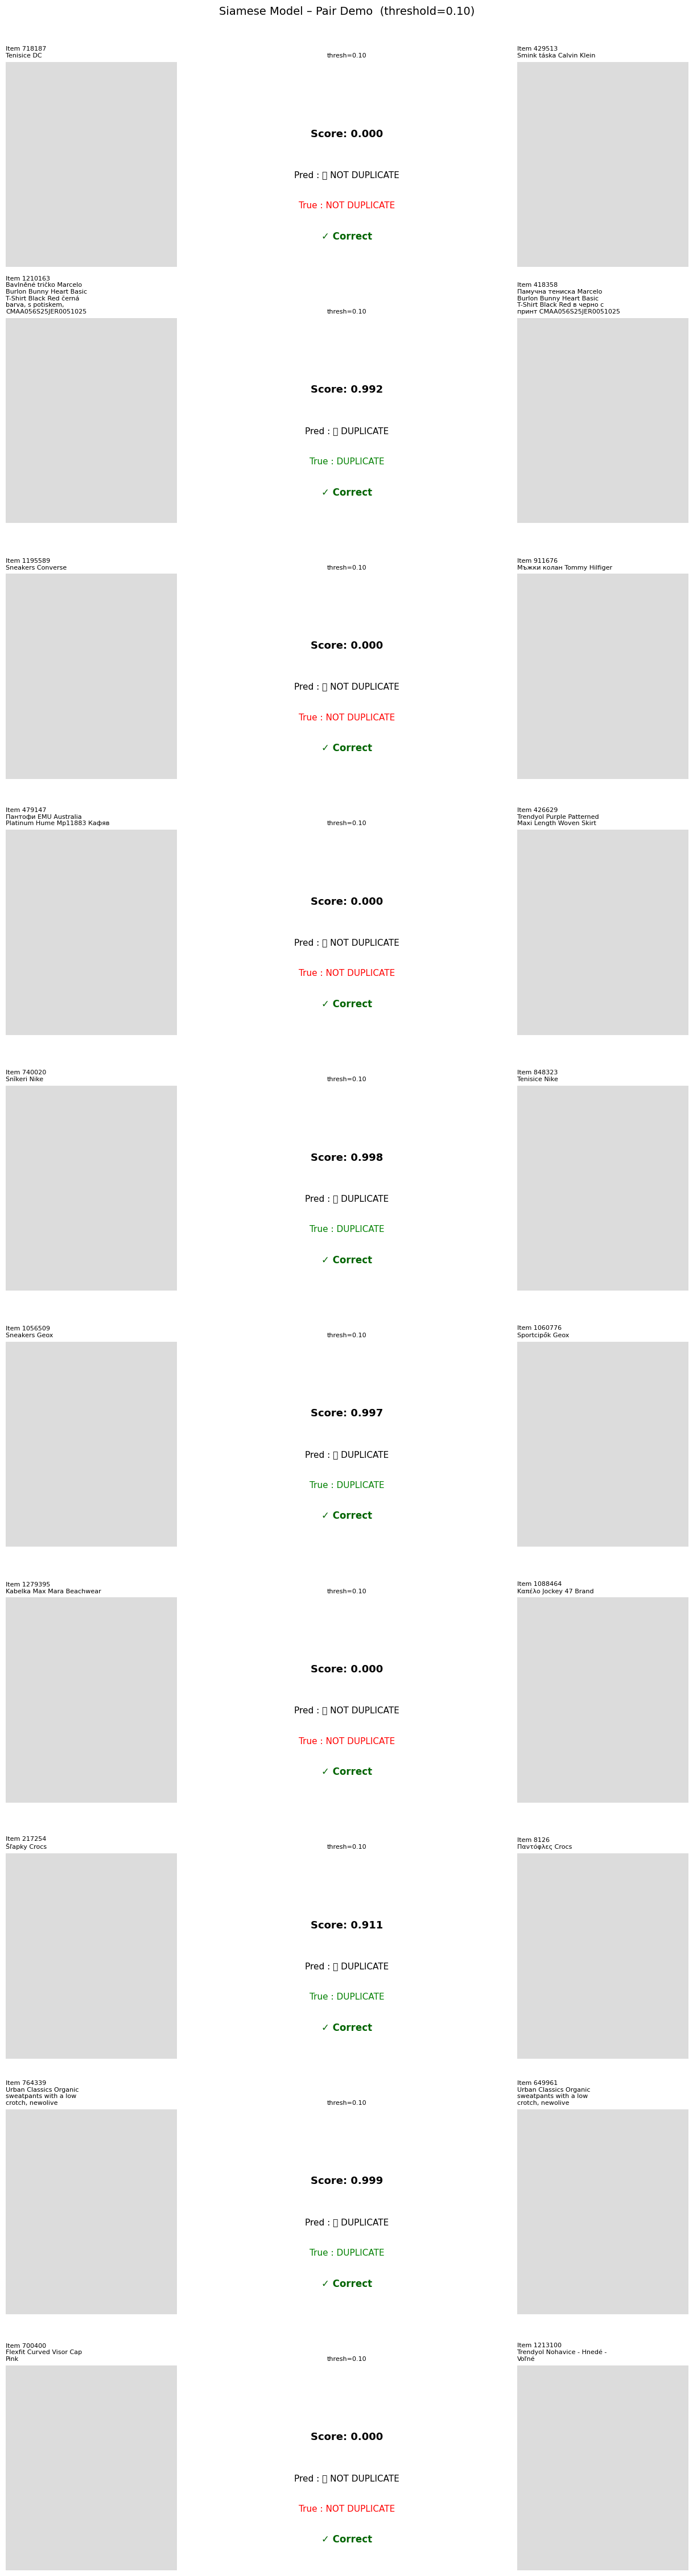

In [ ]:
def show_pair_demo(n_pos=5, n_neg=5, threshold=None):
    """Show n_pos duplicate pairs and n_neg non-duplicate pairs with model predictions."""
    if threshold is None:
        threshold = THRESHOLD

    pos_sample = val_siamese.pairs[val_siamese.pairs['is_duplicate'] == 1].sample(n=n_pos, random_state=random.randint(0, 9999))
    neg_sample = val_siamese.pairs[val_siamese.pairs['is_duplicate'] == 0].sample(n=n_neg, random_state=random.randint(0, 9999))
    demo_pairs = pd.concat([pos_sample, neg_sample]).sample(frac=1).reset_index(drop=True)

    model.eval()
    fig, axes = plt.subplots(len(demo_pairs), 3, figsize=(14, 4.5 * len(demo_pairs)))
    if len(demo_pairs) == 1:
        axes = [axes]

    for row_idx, (_, row) in enumerate(demo_pairs.iterrows()):
        id1, id2 = str(int(row['item_id_1'])), str(int(row['item_id_2']))
        true_label = int(row['is_duplicate'])

        # Get model score
        it1 = item_dataset.get_item_by_id(id1)
        it2 = item_dataset.get_item_by_id(id2)
        if it1 is None or it2 is None:
            continue

        def batch1(item):
            return {k: v.unsqueeze(0).to(device) if isinstance(v, torch.Tensor) else v
                    for k, v in item.items() if k != 'item_id'}

        with torch.no_grad():
            score = torch.sigmoid(model(batch1(it1), batch1(it2))).item()
        pred_label = int(score >= threshold)

        correct = pred_label == true_label
        bg_color = '#d4edda' if correct else '#f8d7da'   # green / red
        pred_str = '✅ DUPLICATE' if pred_label == 1 else '❌ NOT DUPLICATE'
        true_str = 'DUPLICATE'   if true_label == 1 else 'NOT DUPLICATE'

        info1 = raw_info.get(int(id1), {})
        info2 = raw_info.get(int(id2), {})

        # Image 1
        ax_img1 = axes[row_idx][0]
        ax_img1.imshow(load_image(id1))
        ax_img1.axis('off')
        ax_img1.set_title(f"Item {id1}\n{wrap_text(info1.get('title', 'N/A'))}",
                          fontsize=8, loc='left')

        # Middle info panel
        ax_mid = axes[row_idx][1]
        ax_mid.set_facecolor(bg_color)
        ax_mid.axis('off')
        ax_mid.text(0.5, 0.65, f"Score: {score:.3f}", ha='center', va='center',
                    fontsize=13, fontweight='bold', transform=ax_mid.transAxes)
        ax_mid.text(0.5, 0.45, f"Pred : {pred_str}", ha='center', va='center',
                    fontsize=11, transform=ax_mid.transAxes)
        ax_mid.text(0.5, 0.30, f"True : {true_str}", ha='center', va='center',
                    fontsize=11, transform=ax_mid.transAxes,
                    color='green' if true_label == 1 else 'red')
        status = '✓ Correct' if correct else '✗ Wrong'
        ax_mid.text(0.5, 0.15, status, ha='center', va='center',
                    fontsize=12, fontweight='bold', transform=ax_mid.transAxes,
                    color='darkgreen' if correct else 'darkred')
        ax_mid.set_title(f"thresh={threshold:.2f}", fontsize=8)

        # Image 2
        ax_img2 = axes[row_idx][2]
        ax_img2.imshow(load_image(id2))
        ax_img2.axis('off')
        ax_img2.set_title(f"Item {id2}\n{wrap_text(info2.get('title', 'N/A'))}",
                          fontsize=8, loc='left')

    plt.suptitle(f"Siamese Model – Pair Demo  (threshold={threshold:.2f})", fontsize=14, y=1.005)
    plt.tight_layout()
    plt.show()


show_pair_demo(n_pos=5, n_neg=5)


## 6. Hard examples – highest-confidence mistakes

In [ ]:
# Build full predictions on the sampled val set to find FP / FN
pair_records = val_siamese.pairs.copy().reset_index(drop=True)
pair_records['prob']  = all_probs
pair_records['pred']  = (all_probs >= THRESHOLD).astype(int)
pair_records['label'] = all_labels.astype(int)

false_positives = pair_records[(pair_records['pred'] == 1) & (pair_records['label'] == 0)].nlargest(5, 'prob')
false_negatives = pair_records[(pair_records['pred'] == 0) & (pair_records['label'] == 1)].nsmallest(5, 'prob')

print(f"Showing top-5 false positives (model most confidently wrong → said DUPLICATE, actually NOT)")
print(false_positives[['item_id_1','item_id_2','prob']].to_string(index=False))
print(f"\nShowing top-5 false negatives (model most confidently wrong → said NOT DUPLICATE, actually IS)")
print(false_negatives[['item_id_1','item_id_2','prob']].to_string(index=False))

In [ ]:
def show_mistakes(mistake_df, title):
    rows = mistake_df.reset_index(drop=True)
    fig, axes = plt.subplots(len(rows), 3, figsize=(14, 4.5 * len(rows)))
    if len(rows) == 1: axes = [axes]

    for row_idx, (_, row) in enumerate(rows.iterrows()):
        id1, id2 = str(int(row['item_id_1'])), str(int(row['item_id_2']))
        score      = row['prob']
        pred_label = int(row['pred'])
        true_label = int(row['label'])
        info1 = raw_info.get(int(id1), {})
        info2 = raw_info.get(int(id2), {})

        ax_img1 = axes[row_idx][0]
        ax_img1.imshow(load_image(id1))
        ax_img1.axis('off')
        ax_img1.set_title(f"Item {id1}\n{wrap_text(info1.get('title','N/A'))}", fontsize=8, loc='left')

        ax_mid = axes[row_idx][1]
        ax_mid.set_facecolor('#f8d7da')
        ax_mid.axis('off')
        pred_str = 'DUPLICATE' if pred_label == 1 else 'NOT DUPLICATE'
        true_str = 'DUPLICATE' if true_label == 1 else 'NOT DUPLICATE'
        ax_mid.text(0.5, 0.65, f"Score: {score:.3f}", ha='center', va='center', fontsize=13, fontweight='bold', transform=ax_mid.transAxes)
        ax_mid.text(0.5, 0.45, f"Pred : {pred_str}", ha='center', va='center', fontsize=11, transform=ax_mid.transAxes)
        ax_mid.text(0.5, 0.30, f"True : {true_str}", ha='center', va='center', fontsize=11, transform=ax_mid.transAxes)
        ax_mid.text(0.5, 0.12, '✗ Wrong', ha='center', va='center', fontsize=12, fontweight='bold', color='darkred', transform=ax_mid.transAxes)

        ax_img2 = axes[row_idx][2]
        ax_img2.imshow(load_image(id2))
        ax_img2.axis('off')
        ax_img2.set_title(f"Item {id2}\n{wrap_text(info2.get('title','N/A'))}", fontsize=8, loc='left')

    plt.suptitle(title, fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()


show_mistakes(false_positives, "Top-5 False Positives (predicted DUPLICATE, truth=NOT DUPLICATE)")
show_mistakes(false_negatives, "Top-5 False Negatives (predicted NOT DUPLICATE, truth=DUPLICATE)")
